# .1. Proyecto júpiter

## 1.1 Introducción
Europcar, empresa líder en el sector del alquiler de vehículos, está evaluando la ampliación de su flota mediante la compra de coches de segunda mano. En este contexto, el objetivo del proyecto es analizar el mercado de vehículos usados para optimizar una inversión de 3 millones de euros, identificando aquellos vehículos más rentables, eficientes y alineados con las necesidades operativas de la compañía.

Para ello, en este notebook se trabajará con dos bases de datos obtenidas mediante técnicas de web scraping procedentes de coches.net. El objetivo principal es construir un dataframe consolidado que reúna los datos clave del proyecto, permitiendo extraer insights para realizar un análisis estratégico que facilite la toma de decisiones de inversión.

# .2. Dataset Coches.net

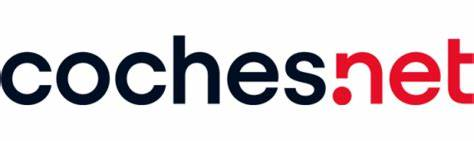

## 2.1 Análisis preliminar



### Contexto

Coches.net España, Esta consolidándose como un referente en la compraventa de vehículos de ocasión, nuevos, km 0 y de renting. Se ha seleccionado como fuente estratégica para este proyecto debido a su elevado volumen de datos, la intensa actividad de usuarios y la amplia variedad de categorías disponibles. Estas características permiten obtener información representativa, actualizada y fiable del mercado automovilístico.

Durante el desarrollo del proyecto se llevaron a cabo dos procesos de extracción de datos en la plataforma. La primera extracción se realizó aplicando un filtro específico para furgonetas, lo que permitió obtener un total de 6.867 registros. Por otro lado, la segunda extracción se efectuó desde la página principal del sitio, donde la oferta está mayoritariamente compuesta por turismos, especialmente coches utilitarios y berlinas, alcanzando en este caso un total de 3.781 registros

### Extracción de datos



#### Beautifulsuop

Comenzamos el proceso de extracción de datos utilizando la herramienta BeautifulSoup; sin embargo, no fue posible obtener más de 1000 registros. A medida que se realizaban nuevos intentos sobre la página, los mecanismos de seguridad se intensificaban, dificultando el acceso a la información.

No obstante, se incluye a continuación el código utilizado como evidencia del proceso realizado, aplicando las herramientas y conocimientos adquiridos en clase.

In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import random

base_url = "https://www.coches.net/vehiculos-industriales/?Section1Id=2900&Section2Id=2930&pg={}"
base_domain = "https://www.coches.net"

coches_links = set()

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120 Safari/537.36",
    "Accept-Language": "es-ES,es;q=0.9"
}

page = 1

while True:

    url = base_url.format(page)
    print(f"Scrapeando página {page}...")

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print("Bloqueado o error")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    coches = soup.find_all("a", class_="mt-CardAd-infoHeaderTitleLink")

    print(f"Encontrados: {len(coches)}")

    if not coches:
        print("No hay más coches → fin")
        break

    for coche in coches:
        href = coche.get("href")
        if href:
            coches_links.add(base_domain + href)

    page += 1

    time.sleep(3 + random.random()*3)

print("Links únicos encontrados:", len(coches_links))


Scrapeando página 1...
Encontrados: 2
Scrapeando página 2...


KeyboardInterrupt: 

In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import random

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "es-ES,es;q=0.9"
}

coches_data = []

def get_text_safe(parent, selector, attr=None):
    try:
        if attr:
            tag = parent.find("li", {"data-qa-selector": selector})
            if tag:
                span = tag.find("span", {"class": "specValue___T9Rmz"})
                return span.text.strip() if span else None
        else:
            tag = parent.find(selector[0], selector[1])
            return tag.get_text(strip=True) if tag else None
    except:
        return None


for link in coches_links:

    try:
        response = requests.get(link, headers=headers)
        soup = BeautifulSoup(response.text, "html.parser")

        coche = soup

        titulo = get_text_safe(coche, ("h1", {"class": "mt-TitleBasic-title"}))

        if not titulo:
            print(f" Sin título: {link}")
            continue

        palabras = titulo.split()
        marca = palabras[0] if len(palabras) > 0 else None
        modelo = " ".join(palabras[1:]) if len(palabras) > 1 else None
        version = titulo

        precio_txt = get_text_safe(coche, ("p", {"class": "mt-CardAdPrice-cashAmount"}))
        precio = None
        if precio_txt:
            precio = float(
                precio_txt.replace(".", "")
                .replace("€", "")
                .replace("\xa0", "")
            )

        combustible = get_text_safe(coche, "spec-fuel", attr=True)

        año = get_text_safe(coche, "spec-year", attr=True)
        año = int(año) if año and año.isdigit() else None

        kilometros = get_text_safe(coche, "spec-mileage", attr=True)
        if kilometros:
            kilometros = float(
                kilometros.replace(".", "")
                .replace("km", "")
                .strip()
            )

        transmision = get_text_safe(coche, "spec-gear", attr=True)

        potencia = None
        puertas = None

        items = coche.find_all("li", class_="mt-PanelAdDetails-dataItem")

        for item in items:
            texto = item.get_text().lower()

            if "cv" in texto and potencia is None:
                strong = item.find("strong")
                if strong:
                    potencia = int(strong.text.strip())

            if "puerta" in texto and puertas is None:
                strong = item.find("strong")
                if strong:
                    puertas = int(strong.text.strip())

        coches_data.append({
            "marca": marca,
            "modelo": modelo,
            "version": version,
            "precio": precio,
            "año": año,
            "kilometros": kilometros,
            "combustible": combustible,
            "transmision": transmision,
            "potencia": potencia,
            "puertas": puertas,
            "link": link
        })

        print(f"OK: {link}")
        time.sleep(5 + random.random()*3)

    except Exception as e:
        print(f"Error en {link}: {e}")
        continue

import pandas as pd

df = pd.DataFrame(coches_data)

df.to_csv("coches_net.csv", index=False)

df.tail(3)


#### Selenium

Después de varios intentos fallidos utilizando la herramienta BeautifulSoup, se tomó la decisión de apoyarse en la inteligencia artificial de ChatGPT para optimizar el proceso de extracción de datos. A partir de esta consulta, se propuso el uso de la herramienta Selenium, cuyo código, al ejecutarse en un entorno local (Visual Studio), permitió consolidar una base de datos de 6867 registros.

Sin embargo, al trasladar este mismo código a Google Colab, no fue posible replicar la extracción de datos. A pesar de intentar realizar las configuraciones, actualizaciones y descargas necesarias, no se logró obtener la información completa. Por este motivo, se incluye el código utilizado como evidencia del proceso, y se procederá a la fase de limpieza de datos utilizando la base obtenida en el entorno local.

In [ ]:
!apt-get update -y

# instalar Chrome oficial
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install -y ./google-chrome-stable_current_amd64.deb

# instalar chromedriver compatible automáticamente
!pip install selenium==4.15.0 webdriver-manager pandas==2.2.2 --quiet


In [ ]:
import tempfile
import random
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

def crear_driver():
    options = Options()

    options.binary_location = "/usr/bin/google-chrome"

    options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")
    options.add_argument("--window-size=1920,1080")

    options.add_argument(f"--user-data-dir={tempfile.mkdtemp()}")

    options.add_argument("--disable-blink-features=AutomationControlled")

    options.add_argument(
        f"user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        f"Chrome/{random.randint(115,120)}.0 Safari/537.36"
    )

    service = Service(ChromeDriverManager().install())

    driver = webdriver.Chrome(service=service, options=options)
    return driver


In [ ]:
driver = crear_driver()
driver.get("https://www.google.com")
print(" DRIVER OK")
driver.quit()


In [ ]:
import time
import random
import pandas as pd
import os

from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

DATA_FILE = "furgonetas_cochesnet.csv"
MAX_PAGES = 80
SAVE_EVERY = 100

def dividir_titulo(titulo):
    if not titulo:
        return None, None, None
    palabras = titulo.split()
    marca = palabras[0] if len(palabras)>0 else None
    modelo = palabras[1] if len(palabras)>1 else None
    version = " ".join(palabras[2:]) if len(palabras)>2 else None
    return marca, modelo, version

def guardar(data):
    pd.DataFrame(data).to_csv(DATA_FILE, index=False)


if os.path.exists(DATA_FILE):
    df_existente = pd.read_csv(DATA_FILE)
    coches_data = df_existente.to_dict("records")
    links_vistos = set(df_existente["link"].tolist())
else:
    coches_data = []
    links_vistos = set()

driver = crear_driver()

for page in range(1, MAX_PAGES + 1):
    url = f"https://www.coches.net/vehiculos-industriales/?MinYear=2015&Section1Id=2900&Section2Id=2930&pg={page}"
    print(f"\n Página {page}")

    try:
        driver.get(url)

        WebDriverWait(driver, 15).until(
            EC.presence_of_all_elements_located(
                (By.CSS_SELECTOR, "a.mt-CardAd-infoHeaderTitleLink")
            )
        )
    except:
        print(" Error cargando página")
        continue

    coches = driver.find_elements(By.CSS_SELECTOR, "a.mt-CardAd-infoHeaderTitleLink")
    links = [c.get_attribute("href") for c in coches if c.get_attribute("href")]

    print(f" {len(links)} anuncios encontrados")

    for link in links:
        if link in links_vistos:
            continue

        try:
            driver.get(link)

            titulo = WebDriverWait(driver, 10).until(
                EC.presence_of_element_located((By.TAG_NAME, "h1"))
            ).text
        except:
            print("⚠ Error en anuncio")
            continue

        marca, modelo, version = dividir_titulo(titulo)

        try:
            precio = driver.find_element(By.CSS_SELECTOR, "p.mt-CardAdPrice-cashAmount").text
        except:
            precio = None

        detalles = driver.find_elements(By.CSS_SELECTOR, "ul.mt-PanelAdDetails-data li")

        año = kilometros = combustible = transmision = potencia = puertas = None

        for d in detalles:
            texto = d.text.lower()

            if "km" in texto:
                kilometros = texto
            elif "puerta" in texto:
                puertas = texto
            elif "cv" in texto:
                potencia = texto
            elif "cambio" in texto:
                transmision = texto.replace("cambio", "").strip()
            elif any(x in texto for x in ["eléctrico", "diesel", "gasolina"]):
                combustible = texto
            elif texto.isdigit() and len(texto) == 4:
                año = texto

        coches_data.append({
            "marca": marca,
            "modelo": modelo,
            "version": version,
            "precio": precio,
            "año": año,
            "kilometros": kilometros,
            "combustible": combustible,
            "transmision": transmision,
            "potencia": potencia,
            "puertas": puertas,
            "link": link
        })

        links_vistos.add(link)

        print(f" {marca} {modelo} | {precio}")

        if len(coches_data) % SAVE_EVERY == 0:
            guardar(coches_data)

        time.sleep(random.uniform(1.5, 3))

driver.quit()
guardar(coches_data)

print(f"\n TOTAL: {len(coches_data)} registros")


In [ ]:
from google.colab import files
files.download("furgonetas_cochesnet.csv")


#### Playwright

Se llevó a cabo un proceso adicional de extracción con el objetivo de incrementar el número de registros en el dataset mediante el uso de Playwright. En esta ocasión, se obtuvieron 3.781 nuevos registros, lo que permitirá disponer de una visión más completa y precisa del objetivo del proyecto.


In [ ]:
# ============================================================
# CELDA 1 - Instalar dependencias y montar Drive
# ============================================================
import subprocess
subprocess.run(['pip', 'install', 'playwright', 'beautifulsoup4', 'lxml', '--quiet'], check=True)
subprocess.run(['playwright', 'install', 'chromium'], check=True)
subprocess.run(['playwright', 'install-deps', 'chromium'], check=True)

from google.colab import drive
drive.mount('/content/drive')

import IPython
IPython.display.display(IPython.display.Javascript("""
function KeepAlive() {
  try {
    document.querySelector('#top-toolbar > colab-connect-button')
      .shadowRoot.querySelector('#connect').click();
  } catch(e) {}
}
setInterval(KeepAlive, 60000);
"""))

print('Dependencias instaladas y Drive montado')

Mounted at /content/drive


<IPython.core.display.Javascript object>

Dependencias instaladas y Drive montado


In [ ]:
# ============================================================
# CELDA 2 - Configuracion de rutas
# ============================================================
import os

CARPETA      = '/content/drive/MyDrive/proyecto_jupiter/'
ARCHIVO_URLS = CARPETA + 'coches_net_urls.txt'
ARCHIVO_CSV  = CARPETA + 'coches_net_datos.csv'
CHECKPOINT   = CARPETA + 'coches_net_checkpoint.txt'

os.makedirs(CARPETA, exist_ok=True)

print('Rutas configuradas:')
print('  URLs     ->', ARCHIVO_URLS)
print('  CSV      ->', ARCHIVO_CSV)
print('  Checkpoint ->', CHECKPOINT)

# Estado actual
if os.path.exists(ARCHIVO_URLS):
    with open(ARCHIVO_URLS) as f:
        n_urls = sum(1 for l in f if l.strip().startswith('http'))
    print(f'\nURLs ya guardadas: {n_urls}')
else:
    print('\nNo hay URLs guardadas todavia - se hara Fase 1 completa')

if os.path.exists(ARCHIVO_CSV):
    import pandas as pd
    df_check = pd.read_csv(ARCHIVO_CSV)
    print(f'Vehiculos ya procesados: {len(df_check)}')
else:
    print('No hay CSV todavia - se procesaran todos los vehiculos')

if os.path.exists(CHECKPOINT):
    cp = open(CHECKPOINT).read().strip()
    print(f'Ultimo checkpoint: vehiculo {cp}')
else:
    print('Sin checkpoint - empezara desde el principio')

Rutas configuradas:
  URLs     -> /content/drive/MyDrive/proyecto_jupiter/coches_net_urls.txt
  CSV      -> /content/drive/MyDrive/proyecto_jupiter/coches_net_datos.csv
  Checkpoint -> /content/drive/MyDrive/proyecto_jupiter/coches_net_checkpoint.txt

URLs ya guardadas: 11396
Vehiculos ya procesados: 11100
Ultimo checkpoint: vehiculo 11100


In [ ]:
# ============================================================
# CELDA 3 - Todas las funciones y configuracion del scraper
# ============================================================
import os, asyncio, re, json, time
import pandas as pd
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup

FUENTE = 'coches.net'
CHROMIUM_ARGS = [
    '--no-sandbox', '--disable-setuid-sandbox',
    '--disable-dev-shm-usage', '--disable-gpu',
    '--single-process', '--no-zygote',
]

# Filtros de busqueda
FILTROS = []
base = {'hasPhoto': 'false', 'wwa': 'false'}
combustibles = ['gasolina', 'diesel', 'hibrido', 'electrico']
carrocerias  = ['suv', 'berlina', 'furgoneta', 'familiar', 'coupe', 'monovolumen', 'todoterreno']
precios = [('0','5000'),('5000','10000'),('10000','15000'),('15000','20000'),('20000','30000'),('30000','50000'),('50000','100000')]
anios   = [('2000','2010'),('2010','2015'),('2015','2018'),('2018','2020'),('2020','2022'),('2022','2024')]

for c in combustibles:
    for p1, p2 in precios:
        FILTROS.append({**base, 'fuelType': c, 'priceFrom': p1, 'priceTo': p2})
for c in combustibles:
    for a1, a2 in anios:
        FILTROS.append({**base, 'fuelType': c, 'yearFrom': a1, 'yearTo': a2})
for car in carrocerias:
    for p1, p2 in precios:
        FILTROS.append({**base, 'bodyType': car, 'priceFrom': p1, 'priceTo': p2})
for car in carrocerias:
    for a1, a2 in anios:
        FILTROS.append({**base, 'bodyType': car, 'yearFrom': a1, 'yearTo': a2})
for c in combustibles:
    for car in carrocerias:
        FILTROS.append({**base, 'fuelType': c, 'bodyType': car})

print(f'Filtros preparados: {len(FILTROS)} combinaciones')

# ---- Funciones de normalizacion ----
MAPA_CARROCERIA = {
    'berlina': 'berlina', 'sedan': 'berlina', 'familiar': 'berlina',
    'coupe': 'berlina', 'descapotable': 'berlina', 'cabrio': 'berlina',
    'suv': 'utilitario', 'todoterreno': 'utilitario', '4x4': 'utilitario',
    'monovolumen': 'utilitario', 'pickup': 'utilitario', 'compacto': 'utilitario',
    'furgoneta': 'furgoneta', 'van': 'furgoneta', 'camioneta': 'furgoneta',
}

def normalizar_carroceria(v):
    if not v:
        return None
    c = str(v).lower().strip()
    for p, cat in MAPA_CARROCERIA.items():
        if p in c:
            return cat
    return c

def normalizar_combustible(v):
    if not v:
        return None
    t = str(v).lower()
    if 'diesel' in t or 'gasoil' in t:
        return 'Diesel'
    if 'gasolina' in t or 'petrol' in t:
        return 'Gasolina'
    if 'hibrido' in t or 'hybrid' in t:
        return 'Hibrido'
    if 'electri' in t:
        return 'Electrico'
    if 'glp' in t or 'gnl' in t:
        return 'Gas'
    return str(v).strip().capitalize()

def normalizar_transmision(v):
    if not v:
        return None
    t = str(v).lower()
    if 'manual' in t:
        return 'Manual'
    if 'autom' in t:
        return 'Automatico'
    return str(v).strip().capitalize()

def limpiar_numero(v):
    if v is None:
        return None
    l = re.sub(r'[^\d]', '', str(v))
    return int(l) if l else None

def extraer_links_covo(html):
    links = set()
    for href in re.findall(r'href="([^"]*covo\.aspx[^"]*)"', html, re.IGNORECASE):
        if href.startswith('http'):
            links.add(href)
        elif href.startswith('/'):
            links.add('https://www.coches.net' + href)
    return links

def extraer_json_ld(soup):
    d = {}
    for script in soup.find_all('script', type='application/ld+json'):
        try:
            s = json.loads(script.string or '{}')
            tipo = s.get('@type', '')
            tipos = tipo if isinstance(tipo, list) else [tipo]
            if not any(t in ['Car', 'Vehicle', 'Product'] for t in tipos):
                continue
            if 'brand' in s:
                b = s['brand']
                d['marca'] = b.get('name') if isinstance(b, dict) else str(b)
            d['modelo'] = s.get('model') or s.get('name')
            if 'offers' in s:
                of = s['offers']
                if isinstance(of, list):
                    of = of[0] if of else {}
                d['precio'] = limpiar_numero(of.get('price'))
            d['anno'] = limpiar_numero(s.get('vehicleModelDate') or s.get('modelDate'))
            od = s.get('mileageFromOdometer')
            d['kilometros'] = limpiar_numero(od.get('value') if isinstance(od, dict) else od)
            d['combustible'] = normalizar_combustible(s.get('fuelType'))
            d['transmision'] = normalizar_transmision(s.get('vehicleTransmission'))
            d['carroceria']  = normalizar_carroceria(s.get('bodyType'))
            pot = s.get('vehicleEngine') or s.get('power')
            if isinstance(pot, dict):
                pot = pot.get('enginePower') or pot.get('value')
            d['potencia'] = limpiar_numero(pot)
            break
        except Exception:
            continue
    return d

def extraer_html(soup):
    d = {}
    h1 = soup.find(class_=re.compile('TitleBasic-title')) or soup.find('h1')
    if h1:
        partes = h1.get_text(separator=' ', strip=True).split()
        if len(partes) >= 1:
            d['marca'] = partes[0]
        if len(partes) >= 2:
            d['modelo'] = partes[1]
    texto = soup.get_text(' ', strip=True)
    m = re.search(r'\b(20[012]\d)\b', texto)
    if m:
        d['anno'] = int(m.group(1))
    m = re.search(r'([\d\.]+)\s*km', texto, re.IGNORECASE)
    if m:
        d['kilometros'] = limpiar_numero(m.group(1))
    m = re.search(r'(\d{2,4})\s*cv', texto, re.IGNORECASE)
    if m:
        d['potencia'] = int(m.group(1))
    for c in ['Gasolina', 'Diesel', 'Hibrido', 'Electrico', 'GLP']:
        if c.lower() in texto.lower():
            d['combustible'] = normalizar_combustible(c)
            break
    if re.search(r'Manual\b', texto):
        d['transmision'] = 'Manual'
    elif re.search(r'Autom', texto):
        d['transmision'] = 'Automatico'
    for tipo in ['SUV', 'Berlina', 'Familiar', 'Coupe', 'Descapotable', 'Monovolumen', 'Todoterreno', 'Furgoneta', 'Pickup']:
        if tipo in texto:
            d['carroceria'] = normalizar_carroceria(tipo)
            break
    return d

def procesar_html(html):
    campos = ['marca', 'modelo', 'precio', 'anno', 'kilometros', 'combustible', 'transmision', 'potencia', 'fuente', 'carroceria']
    reg = {k: None for k in campos}
    reg['fuente'] = FUENTE
    soup = BeautifulSoup(html, 'lxml')
    for k, v in extraer_json_ld(soup).items():
        if v is not None and k in reg:
            reg[k] = v
    vacios = [k for k in campos if k != 'fuente' and reg[k] is None]
    if vacios:
        for k, v in extraer_html(soup).items():
            if k in vacios and v is not None:
                reg[k] = v
    return reg

print('Funciones cargadas correctamente')

Filtros preparados: 171 combinaciones
Funciones cargadas correctamente


In [ ]:
# ============================================================
# CELDA 4 - FASE 1: Recoger URLs
# Solo se ejecuta si no hay URLs guardadas ya
# ============================================================
async def fase1():
    urls_totales = set()

    if os.path.exists(ARCHIVO_URLS):
        with open(ARCHIVO_URLS) as f:
            urls_totales = set(l.strip() for l in f if l.strip().startswith('http'))
        print(f'URLs ya en Drive: {len(urls_totales)} - buscando mas...')
    else:
        print('FASE 1 - Recogiendo URLs...')

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True, args=CHROMIUM_ARGS)
        pg = await browser.new_page()
        for i, filtro in enumerate(FILTROS):
            print(f'  [{i+1}/{len(FILTROS)}] Filtro: {[v for k,v in filtro.items() if k not in ["hasPhoto","wwa"]]}')
            pagina = 1
            vacias = 0
            while True:
                params = '&'.join(f'{k}={v}' for k, v in {**filtro, 'pg': pagina}.items())
                url = f'https://www.coches.net/search/?{params}'
                try:
                    await pg.goto(url, wait_until='domcontentloaded', timeout=60000)
                    await pg.wait_for_timeout(5000)
                    html = await pg.content()
                    nuevas = extraer_links_covo(html) - urls_totales
                    urls_totales.update(nuevas)
                    if nuevas:
                        with open(ARCHIVO_URLS, 'a') as f:
                            f.write('\n'.join(nuevas) + '\n')
                        vacias = 0
                    else:
                        vacias += 1
                    print(f'  Pagina {pagina}: +{len(nuevas)} | Total: {len(urls_totales)}')
                    if vacias >= 3:
                        break
                    pagina += 1
                    await asyncio.sleep(2)
                except Exception as e:
                    print(f'  Error: {e}')
                    break
        await browser.close()

    print(f'\nFASE 1 completada - {len(urls_totales)} URLs guardadas en Drive')
    return list(urls_totales)

print('Funcion fase1 lista')

Funcion fase1 lista


In [ ]:
# ============================================================
# CELDA 5 - FASE 2: Extraer datos de cada coche
# Retoma automaticamente desde el checkpoint si se interrumpio
# ============================================================
async def fase2(urls):
    print(f'\nFASE 2 - Extrayendo datos de {len(urls)} coches...')
    todos = []
    inicio = 0

    if os.path.exists(ARCHIVO_CSV) and os.path.exists(CHECKPOINT):
        try:
            todos = pd.read_csv(ARCHIVO_CSV).to_dict('records')
            inicio = int(open(CHECKPOINT).read().strip())
            print(f'Retomando desde vehiculo {inicio+1} de {len(urls)}')
        except Exception:
            todos = []
            inicio = 0
    else:
        print('Empezando desde el principio')

    pendientes = urls[inicio:]
    if not pendientes:
        print('Ya estaban todos procesados')
        return pd.read_csv(ARCHIVO_CSV)

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True, args=CHROMIUM_ARGS)
        page = await browser.new_page()
        total = len(urls)
        for i, url in enumerate(pendientes, start=inicio):
            num = i + 1
            print(f'[{num}/{total}] {url[:80]}')
            try:
                await page.goto(url, wait_until='domcontentloaded', timeout=60000)
                await page.wait_for_timeout(3000)
                html = await page.content()
                registro = procesar_html(html)
            except Exception as e:
                print(f'  Error: {e}')
                registro = {'fuente': FUENTE}
            todos.append(registro)
            if num % 100 == 0:
                pd.DataFrame(todos).to_csv(ARCHIVO_CSV, index=False)
                open(CHECKPOINT, 'w').write(str(num))
                print(f'  Checkpoint guardado: {num} vehiculos en Drive')
            await asyncio.sleep(2)
        await browser.close()

    df = pd.DataFrame(todos)
    df.to_csv(ARCHIVO_CSV, index=False)
    open(CHECKPOINT, 'w').write(str(len(todos)))
    print(f'\nFASE 2 completada - {len(df)} vehiculos guardados en Drive')
    return df

print('Funcion fase2 lista')

Funcion fase2 lista


In [ ]:
# ============================================================
# CELDA 6 - PIPELINE COMPLETO
# Detecta automaticamente si ya tienes URLs o datos guardados
# y retoma desde donde se quedo
# ============================================================
async def pipeline_completo():
    print('='*60)
    print('PROYECTO JUPITER - SCRAPING COCHES.NET')
    print('='*60)

    # Fase 1: obtener URLs (si ya estan guardadas las reutiliza)
    if os.path.exists(ARCHIVO_URLS):
        with open(ARCHIVO_URLS) as f:
            urls = [l.strip() for l in f if l.strip().startswith('http')]
        print(f'URLs ya disponibles en Drive: {len(urls)} - saltando Fase 1')
    else:
        print('No hay URLs guardadas - ejecutando Fase 1 completa')
        urls = await fase1()

    # Fase 2: extraer datos (retoma desde checkpoint si existe)
    df = await fase2(urls)

    print('\n' + '='*60)
    print('DATASET FINAL LISTO')
    print(f'Vehiculos totales : {len(df)}')
    print(f'Archivo CSV       : {ARCHIVO_CSV}')
    print('\nCompletitud de campos (%):')
    print(df.notna().mean().mul(100).round(1).to_string())
    print('\nMuestra de los primeros registros:')
    print(df[['marca','modelo','precio','anno','kilometros','combustible','carroceria']].head(10).to_string())
    print('='*60)
    return df

df_final = await pipeline_completo()

Se han truncado las últimas 5000 líneas del flujo de salida.
  Error: Page.goto: Target page, context or browser has been closed
[8653/11396] https://www.coches.net/audi-a3-sedan-16-tdi-clean-110cv-attraction-4p-diesel-201
  Error: Page.goto: Target page, context or browser has been closed
[8654/11396] https://www.coches.net/bmw-serie-3-320d-autotouring-5p-electrico-hibrido-2023-en
  Error: Page.goto: Target page, context or browser has been closed
[8655/11396] https://www.coches.net/renault-trafic-diesel-2026-en-asturias-70478815-covo.aspx
  Error: Page.goto: Target page, context or browser has been closed
[8656/11396] https://www.coches.net/bmw-serie-3-320d-autotouring-5p-electrico-hibrido-2023-en
  Error: Page.goto: Target page, context or browser has been closed
[8657/11396] https://www.coches.net/seat-arona-10-tsi-81kw-110cv-style-5p-gasolina-2021-en-ba
  Error: Page.goto: Target page, context or browser has been closed
[8658/11396] https://www.coches.net/seat-arona-10-tsi-85kw-11

In [ ]:
# ============================================================
# CELDA 7 - Resumen del dataset obtenido
# Ejecuta esta celda cuando haya terminado para ver el resumen
# ============================================================
import pandas as pd

df = pd.read_csv(ARCHIVO_CSV)

print('RESUMEN FINAL DEL DATASET')
print('='*50)
print(f'Total vehiculos     : {len(df)}')
print(f'Columnas            : {list(df.columns)}')
print()
print('Completitud por campo (%):')
print(df.notna().mean().mul(100).round(1).to_string())
print()
print('Distribucion por carroceria:')
print(df['carroceria'].value_counts().to_string())
print()
print('Distribucion por combustible:')
print(df['combustible'].value_counts().to_string())
print()
print('Precio medio por carroceria:')
print(df.groupby('carroceria')['precio'].mean().round(0).to_string())
print()
print(f'CSV guardado en: {ARCHIVO_CSV}')

RESUMEN FINAL DEL DATASET
Total vehiculos     : 11100
Columnas            : ['marca', 'modelo', 'precio', 'anno', 'kilometros', 'combustible', 'transmision', 'potencia', 'fuente', 'carroceria']

Completitud por campo (%):
marca           35.5
modelo          35.5
precio          34.1
anno            35.5
kilometros      35.5
combustible     35.5
transmision     34.1
potencia        35.5
fuente         100.0
carroceria      35.5

Distribucion por carroceria:
carroceria
berlina       2035
utilitario    1809
furgoneta       78
pick up         13

Distribucion por combustible:
combustible
Gasolina              1450
Diésel                1310
Híbrido                758
Híbrido enchufable     300
Eléctrico               87
Gas                     26
Gas natural (cng)        5

Precio medio por carroceria:
carroceria
berlina       20150.0
furgoneta         NaN
pick up       36406.0
utilitario    25307.0

CSV guardado en: /content/drive/MyDrive/proyecto_jupiter/coches_net_datos.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/proyecto_jupiter/coches_net_datos.csv')

# Quedarse solo con filas que tengan al menos marca, precio y kilometros
df_limpio = df.dropna(subset=['marca', 'precio', 'kilometros'])

print(f'Total original  : {len(df)}')
print(f'Registros validos: {len(df_limpio)}')
print(f'Descartados     : {len(df) - len(df_limpio)}')

# Guardar el limpio
ARCHIVO_LIMPIO = '/content/drive/MyDrive/proyecto_jupiter/coches_net_LIMPIO.csv'
df_limpio.to_csv(ARCHIVO_LIMPIO, index=False, encoding='utf-8-sig')
print(f'\nCSV limpio guardado en: {ARCHIVO_LIMPIO}')
print(df_limpio[['marca','modelo','precio','anno','kilometros','combustible','carroceria']].head(5).to_string())

Total original  : 11100
Registros validos: 3781
Descartados     : 7319

CSV limpio guardado en: /content/drive/MyDrive/proyecto_jupiter/coches_net_LIMPIO.csv
        marca   modelo   precio    anno  kilometros combustible  carroceria
0  VOLKSWAGEN     GOLF  15000.0  2014.0    140000.0      Diésel     berlina
1     PEUGEOT   RIFTER  14000.0  2020.0    170000.0      Diésel  utilitario
2     PEUGEOT     2008   8500.0  2016.0    100000.0    Gasolina  utilitario
3         BMW  SERIE 3  11000.0  2014.0    230000.0      Diésel     berlina
4        AUDI       Q7  40000.0  2018.0    260000.0      Diésel  utilitario


### Dataset para análisis




Comenzamos el proceso de tratamiento de datos mediante la lectura de los datasets obtenidos a partir de la extracción de la página coches.net, y convirtiéndolos en un dataframe utilizando la librería Pandas.

El primer conjunto de datos resultante está compuesto por 11 variables: marca, modelo, versión, precio, año, kilometraje, tipo de combustible, transmisión, potencia, número de puertas y link, con un total de 6.867 registros.

In [ ]:
import pandas as pd
df = pd.read_csv("/content/2.furgonetas_cochesnet.csv")
df.tail(2)

,marca,modelo,version,precio,año,kilometros,combustible,transmision,potencia,puertas,link
6867,Citroën,Jumper,2.2 BlueHDi 140CV L2H2,29000,2023.0,51900,Diésel,M,135,5.0,https://www.coches.net/vehiculos-industriales/...
6868,Renault,Kangoo,1.5 Blue dCi 95CV Rapid,21100,2021.0,63300,DIESEL,M6,100,5.0,https://www.coches.net/vehiculos-industriales/...


Antes de comenzar la limpieza de los datos se establecen las mismas columnas en ambos datasets para poder unificarlos

- Se renombra la columna link a fuente, con el fin de identificar claramente el origen de los datos.
- Se estandariza el valor de la columna fuente como “coches.net” en todas sus filas.
- Se crea una nueva columna denominada carrocería, con el objetivo de identificar la categoría de cada vehículo.
- Se eliminan las columnas puertas y versión, ya que no serán utilizadas en el análisis posterior.

In [ ]:
df = df.rename(columns={"link": "fuente"})

df["fuente"] = "coches.net"
df["carroceria"] = "furgoneta"

df_1 = df.drop(columns=["puertas", "version"], errors="ignore")


In [ ]:
df_1.head(2)

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
0,Ford,Transit,18600,2023.0,49800,Hybrid,MANUAL,175,coches.net,furgoneta
1,Renault,Master,37000,2022.0,65400,Electric,M,105,coches.net,furgoneta


Para el segundo conjunto de datos, se realizó la extracción utilizando las 10 variables definidas por el equipo de trabajo para la elaboración del proyecto. Este conjunto está compuesto por un total de 3.781 registros.

Además, se realizaron ajustes para garantizar la coherencia con el otro dataset: se renombró la variable año para asegurar su correspondencia y se estandarizó la variable potencia, dividiendo sus valores entre 100, ya que originalmente presentaba dos dígitos adicionales.

In [ ]:
import pandas as pd
df_2 = pd.read_csv("/content/1.coches_net_playwrigth.csv")

In [ ]:
df_2 = df_2.rename(columns={"anno": "año"})

In [ ]:
df_2['potencia'] = (df_2['potencia'] // 100)

In [ ]:
df_2.tail(2)

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
3779,AUDI,Q7,48990.0,2021.0,84615.0,Híbrido,Automatico,231.0,coches.net,utilitario
3780,KIA,CARENS,11450.0,2016.0,96114.0,Gasolina,Manual,135.0,coches.net,utilitario


Se realiza la unificación de los dos datasets, dando como resultado un dataframe de 10648 registros.

In [ ]:
df_u = pd.concat([df_1, df_2], ignore_index=True)

In [ ]:
df_u.tail(1)

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
10649,KIA,CARENS,11450.0,2016.0,96114.0,Gasolina,Manual,135.0,coches.net,utilitario


In [ ]:
df_u.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10650 entries, 0 to 10649
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   marca        10623 non-null  object 
 1   modelo       10603 non-null  object 
 2   precio       10500 non-null  object 
 3   año          10531 non-null  float64
 4   kilometros   10371 non-null  object 
 5   combustible  10488 non-null  object 
 6   transmision  10541 non-null  object 
 7   potencia     10454 non-null  object 
 8   fuente       10650 non-null  object 
 9   carroceria   10650 non-null  object 
dtypes: float64(1), object(9)
memory usage: 832.2+ KB


In [ ]:
df_unido = df_u.to_csv("3.coches.net_unido.csv", index=False)

## 2.2 Limpieza y tratamiento de datos

In [ ]:
import pandas as pd
df = pd.read_csv("//content/3.coches.net_unido.csv")
df.tail(2)

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
10648,AUDI,Q7,48990.0,2021.0,84615.0,Híbrido,Automatico,231.0,coches.net,utilitario
10649,KIA,CARENS,11450.0,2016.0,96114.0,Gasolina,Manual,135.0,coches.net,utilitario


### Estandarización de formatos
Se define un apartado de estandarización de formatos con el objetivo de asegurar la coherencia entre los distintos datasets utilizados en el análisis.

En este proceso se realizaron las siguientes transformaciones para las columnas numéricas:

- En las variables numéricas (precio, kilómetros y potencia), se eliminan caracteres y signos de puntuación, y se asignan los tipos de datos adecuados.
- En la columna año, se detectan valores con dos dígitos que corresponden al año; por ello, se aplica una función lambda para convertirlos a formato de cuatro dígitos, ademas se deja el tipo de dato como numero entero



In [ ]:
df["precio"] = df["precio"].str.replace("€", "").str.replace(",", "").astype(float)

In [ ]:
df["kilometros"] = pd.to_numeric(df["kilometros"]
    .astype(str)
    .str.lower()
    .str.replace("km", "", regex=False)
    .str.strip(),
    errors="coerce")

In [ ]:
df["potencia"] = pd.to_numeric(df["potencia"].astype(str).str.replace("cv", "", case=False),errors="coerce").astype("Int64")

In [ ]:
df = df[df["potencia"] != 2]

In [ ]:
df["año"] = df["año"].apply(lambda x: 2000 + x if x < 50 else x)

In [ ]:
df['año'] = pd.to_numeric(df['año'], errors='coerce').astype('Int64')

In [ ]:
df["año"].value_counts().sort_index()

,count
año,
1997,1
2000,2
2001,1
2002,2
2003,3
2004,8
2005,13
2006,27
2007,30


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10453 entries, 0 to 10649
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   marca        10426 non-null  object 
 1   modelo       10407 non-null  object 
 2   precio       10306 non-null  float64
 3   año          10339 non-null  Int64  
 4   kilometros   10181 non-null  float64
 5   combustible  10296 non-null  object 
 6   transmision  10348 non-null  object 
 7   potencia     10453 non-null  Int64  
 8   fuente       10453 non-null  object 
 9   carroceria   10453 non-null  object 
dtypes: Int64(2), float64(2), object(6)
memory usage: 918.7+ KB


En las columnas categóricas se realizaron los siguientes ajustes:

- Se normalizó el formato del texto, convirtiendo todos los valores a minúsculas y eliminando espacios innecesarios.
- Se estandarizaron los valores de las variables combustible y transmisión para asegurar consistencia en sus categorías.

In [ ]:
c_texto = df.select_dtypes(include='object').columns

df[c_texto] = df[c_texto].apply(lambda x: x.str.lower().str.strip())

In [ ]:
df["combustible"].value_counts()

,count
combustible,
diesel,2089
diésel,2049
gasolina,2027
gasoil,1403
híbrido,862
híbrido enchufable,300
eléctrico,278
electric,207
ev,189


In [ ]:
df["combustible"] = (df["combustible"].str.strip().str.lower()
.replace({"diesel": "diesel",
          "diésel": "diesel",
          "gasoil": "diesel",
          "gasolina": "gasolina",
          "electric": "electrico",
          "ev": "electrico",
          "eléctrico": "electrico",
          "eléctrico (bev)": "electrico",
          "mhev": "hibrido",
          "hybrid": "hibrido",
          "híbrido": "hibrido",
          "híbrido enchufable": "hibrido",
          "glp/gasolina": "gas",
          "autogás": "gas",
          "glp": "gas",
          "cng": "gas",
          "gnc": "gas",
          "gas natural": "gas",
          "gas natural (cng)": "gas",
          "gas": "gas",}))

In [ ]:
df["combustible"].value_counts()

,count
combustible,
diesel,5541
gasolina,2027
hibrido,1424
electrico,1005
gas,299


In [ ]:
df["transmision"].value_counts()

,count
transmision,
manual,4856
automatico,1945
m,1064
m6,1023
automático,503
at,255
auto,238
automática,238
dsg,226


In [ ]:
df["transmision"] = (df["transmision"].str.strip().str.lower().replace({
        "m": "manual",
        "m6": "manual",
        "manual": "manual",
        "automático": "automatica",
        "at": "automatica",
        "auto": "automatica",
        "automática": "automatica",
        "dsg": "automatica",
        "automatico": "automatica"}))

In [ ]:
df["transmision"].value_counts()

,count
transmision,
manual,6943
automatica,3405


### Tratamiento de nulos y duplicados

Se identifica la presencia de valores nulos en todas las columnas, excepto en fuente y carrocería. Estos valores nulos corresponden a información no disponible en la página web. Dado que ninguna de las columnas presenta más de un 3% de datos faltantes, se opta por eliminar estos registros utilizando la función dropna(), evitando así introducir sesgos derivados de imputaciones innecesarias.

Asimismo, se detectan 205 registros duplicados en el dataset, los cuales son eliminados mediante la función drop_duplicates() con el fin de garantizar la calidad y consistencia de los datos.

Como resultado de este proceso de limpieza, se obtiene un dataframe depurado, sin valores nulos ni duplicados, compuesto por 10 columnas y 9.527 registros.

In [ ]:
tabla_nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje": df.isnull().mean().round(4) * 100
})

print(tabla_nulos)

             nulos  porcentaje
marca           27        0.26
modelo          46        0.44
precio         147        1.41
año            114        1.09
kilometros     272        2.60
combustible    157        1.50
transmision    105        1.00
potencia         0        0.00
fuente           0        0.00
carroceria       0        0.00


In [ ]:
df2 = df.dropna(subset=["marca"])
df2 = df2.dropna(subset=["modelo"])
df2 = df2.dropna(subset=["precio"])
df2 = df2.dropna(subset=["año"])
df2 = df2.dropna(subset=["kilometros"])
df2 = df2.dropna(subset=["combustible"])
df2 = df2.dropna(subset=["transmision"])
df2 = df2.dropna(subset=["potencia"])

In [ ]:
df2.isnull().sum()

,0
marca,0
modelo,0
precio,0
año,0
kilometros,0
combustible,0
transmision,0
potencia,0
fuente,0
carroceria,0


In [ ]:
df2.duplicated().sum()

np.int64(205)

In [ ]:
df2[df2.duplicated(keep=False)]

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
6887,jeep,avenger,16990.0,2024,71000.0,gasolina,manual,100,coches.net,utilitario
6894,mercedes-benz,gla,29990.0,2023,64500.0,hibrido,automatica,218,coches.net,utilitario
6943,volkswagen,t-cross,16985.0,2023,75230.0,gasolina,manual,95,coches.net,utilitario
6972,audi,q3,38985.0,2023,13458.0,hibrido,automatica,245,coches.net,utilitario
6973,audi,q3,38985.0,2023,13458.0,hibrido,automatica,245,coches.net,utilitario
...,...,...,...,...,...,...,...,...,...,...
10601,dacia,duster,12990.0,2018,87091.0,gasolina,manual,115,coches.net,utilitario
10602,dacia,duster,12990.0,2018,87091.0,gasolina,manual,115,coches.net,utilitario
10606,volvo,xc60,27985.0,2021,132891.0,hibrido,automatica,340,coches.net,utilitario
10607,volvo,xc60,27985.0,2021,132891.0,hibrido,automatica,340,coches.net,utilitario


In [ ]:
df2 = df2.drop_duplicates()

In [ ]:
df2.shape

(9527, 10)

### Dataframe inicial

Se guarda el dataset inicial en un archivo CSV con el objetivo de preservar el estado del procesamiento realizado hasta el momento y facilitar la trazabilidad del trabajo. A partir de este archivo se comenzará el análisis exploratorio de datos (EDA).

In [ ]:
df3 = df2.to_csv("4.coches.net_inicial.csv", index=False)

## 2.3 EDA (coches.net)



In [ ]:
import pandas as pd
import numpy as np
df_f = pd.read_csv("/content/4.coches.net_inicial.csv")

### Comprensión de la estructura de los datos

Para la estructuración de este EDA, se define un apartado de comprensión de la estructura de los datos, cuyo objetivo es obtener una visión general del dataframe. En esta sección se incluyen los siguientes elementos:

- Visualización de las columnas del dataframe, compuesto por: marca, modelo, precio, año, kilómetros, combustible, transmisión, potencia, fuente y carrocería.
- Definición de un diccionario de datos que describe el significado de cada variable.
- Visualización de las primeras 5 filas del dataset.
- Visualización de las últimas 5 filas.
- Selección de 5 filas aleatorias para observar la variabilidad de los datos.
- Finalmente, verificación de la información general del dataframe (tipos de datos y estructura).

In [ ]:
df_f.columns

Index(['marca', 'modelo', 'precio', 'año', 'kilometros', 'combustible',
       'transmision', 'potencia', 'fuente', 'carroceria'],
      dtype='object')

**Tabla diccionario de datos**

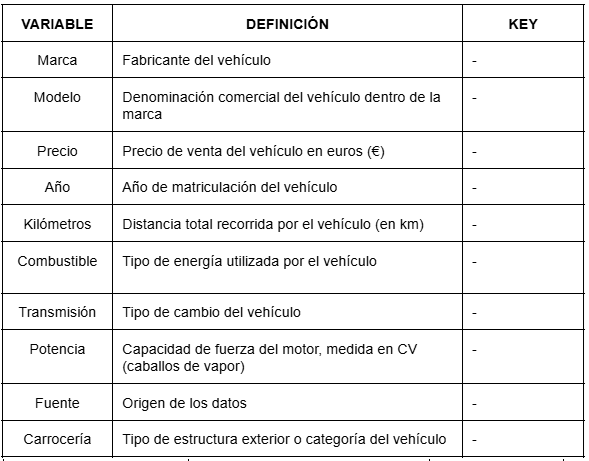

In [ ]:
df_f.head()

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
0,ford,transit,18600.0,2023,49800.0,hibrido,manual,175,coches.net,furgoneta
1,renault,master,37000.0,2022,65400.0,electrico,manual,105,coches.net,furgoneta
2,toyota,proace city,17200.0,2021,100200.0,diesel,automatica,100,coches.net,furgoneta
3,mercedes-benz,sprinter,16700.0,2021,126100.0,diesel,manual,150,coches.net,furgoneta
4,fiat,ducato,40200.0,2023,51900.0,electrico,automatica,165,coches.net,furgoneta


In [ ]:
df_f.tail()

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
9522,seat,tarraco,32199.0,2022,62389.0,diesel,automatica,150,coches.net,utilitario
9523,opel,grandland x,16500.0,2019,38391.0,diesel,manual,130,coches.net,utilitario
9524,bmw,x4,45990.0,2023,76176.0,hibrido,automatica,190,coches.net,utilitario
9525,audi,q7,48990.0,2021,84615.0,hibrido,automatica,231,coches.net,utilitario
9526,kia,carens,11450.0,2016,96114.0,gasolina,manual,135,coches.net,utilitario


In [ ]:
df_f.sample(5)

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
1381,mercedes-benz,vito,42300.0,2023,36700.0,electrico,manual,102,coches.net,furgoneta
3028,peugeot,expert,18900.0,2023,42900.0,diesel,manual,150,coches.net,furgoneta
7627,mercedes-benz,clase glc,31499.0,2018,65005.0,diesel,automatica,170,coches.net,utilitario
3033,man,tge,20600.0,2019,131600.0,diesel,manual,140,coches.net,furgoneta
8699,mercedes-benz,clase cls,6990.0,2006,275000.0,gasolina,automatica,292,coches.net,berlina


En la revisión de la información general del dataframe se identifican los siguientes aspectos:

- El dataset está compuesto por 10 columnas y 9527 filas, indexadas desde la posición 0 hasta la 9526.
- No se presentan valores nulos en ninguna de las variables.
- Las variables marca, modelo, combustible, transmisión, fuente y carrocería son de tipo object (texto).
- Las variables precio y kilómetros son de tipo float, mientras que las variables año y potencia son numeros enteros.

In [ ]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9527 entries, 0 to 9526
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   marca        9527 non-null   object 
 1   modelo       9527 non-null   object 
 2   precio       9527 non-null   float64
 3   año          9527 non-null   int64  
 4   kilometros   9527 non-null   float64
 5   combustible  9527 non-null   object 
 6   transmision  9527 non-null   object 
 7   potencia     9527 non-null   int64  
 8   fuente       9527 non-null   object 
 9   carroceria   9527 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 744.4+ KB


### Análisis descriptivo

Al iniciar el análisis descriptivo, se observa que la columna precio presenta valores atípicos, tanto extremadamente altos como inusualmente bajos, los cuales distorsionan la distribución de los datos.

In [ ]:
df_f.describe()

,precio,año,kilometros,potencia
count,9.527000e+03,9527.000000,9527.000000,9527.000000
mean,4.298319e+04,2020.633148,95743.130366,134.242994
std,2.259857e+05,3.289593,67521.391614,55.587775
min,2.000000e+00,1997.000000,1.000000,23.000000
25%,1.560000e+04,2019.000000,45000.000000,102.000000
50%,2.140000e+04,2021.000000,81800.000000,120.000000
75%,2.780000e+04,2023.000000,131633.000000,150.000000
max,5.080000e+06,2026.000000,426000.000000,670.000000


Se realiza la visualización de los cuartiles 0,90; 0,95; 0,99 y 0,999, y se observa un salto exagerado en el precio a partir del cuartil 0,99.

In [ ]:
df_f["precio"].quantile([0.9, 0.95, 0.99, 0.999])

,precio
0.900,34400.0
0.950,39990.0
0.990,202626.0
0.999,3222660.0


Se realiza la visualización de los percentiles 0,0001; 0,001; 0,01 y 0,1, donde se identifican valores atípicamente bajos en los niveles más inferiores de la distribución.

Por ello, se aplica un filtro entre los percentiles 0,0008 y 0,98, lo que permite depurar los extremos y obtener una distribución de datos más estable y representativa.

In [ ]:
df_f["precio"].quantile([0.0001, 0.001, 0.01, 0.1])

,precio
0.0001,2.00
0.0010,1911.04
0.0100,5490.00
0.1000,11000.00


In [ ]:
q_1 = df_f["precio"].quantile(0.0008)
q_2 = df_f["precio"].quantile(0.98)

df_f1 = df_f[(df_f["precio"] >= q_1) & (df_f["precio"] <= q_2)]

In [ ]:
df_f1.shape

(9328, 10)

Comenzamos a profundizar en el EDA mediante el uso de la función .describe(), la cual permite obtener un resumen estadístico de las variables numéricas.

Precio: Se observa un valor mínimo de 1499 € y un máximo de 57500 €, con una media de 21838,24 € y una mediana de 21100 €.

Año: El vehículo más antiguo corresponde al año 1997 y el más reciente al 2026, lo que supone un rango de 29 años.

Kilómetros: El mínimo registrado es de 1 km y el máximo de 426000 km, con una media de 96359,07 km y una mediana de 82100 km.

Potencia: La potencia de los vehículos oscila entre 23 CV y 555 CV.

In [ ]:
df_f1.describe()

,precio,año,kilometros,potencia
count,9328.000000,9328.000000,9328.000000,9328.000000
mean,21838.241638,2020.604846,96336.483276,131.505467
std,8813.718728,3.293796,67461.776253,46.574125
min,1499.000000,1997.000000,1.000000,23.000000
25%,15500.000000,2019.000000,45600.000000,102.000000
50%,21100.000000,2021.000000,82100.000000,120.000000
75%,27292.500000,2023.000000,132500.000000,150.000000
max,57500.000000,2026.000000,426000.000000,555.000000


A continuación, se aplica la función .describe() a las variables de tipo categórico (string), obteniendo los siguientes resultados:

Se identifican 57 marcas diferentes en el dataset, siendo Ford la más frecuente, con un total de 906 registros.
Existen 5 tipos de combustible, destacando el diésel como el predominante, con 5.038 registros.
Se observan 2 tipos de transmisión, donde la transmisión manual es claramente dominante, con 6.280 registros.
La única fuente de los datos es Coches.net.
Finalmente, se identifican 4 tipos de carrocería. Debido a que una parte significativa de la extracción se ha centrado en furgonetas, esta categoría es la predominante, con 5.859 registros.

In [ ]:
df_f1.select_dtypes(include='object').describe()

,marca,modelo,combustible,transmision,fuente,carroceria
count,9328,9328,9328,9328,9328,9328
unique,57,440,5,2,1,4
top,ford,daily,diesel,manual,coches.net,furgoneta
freq,906,345,5038,6280,9328,5859


Se realiza la visualización de las marcas presentes en el dataset y su respectivo peso porcentual.

Las tres marcas más representativas son Ford, con 906 vehículos (9,71%), seguida de Volkswagen con 902 vehículos (9,67%) y Mercedes-Benz con 895 vehículos (9,59%). Por otro lado, la marca con menor presencia es LEAPMOTOR, con 1 vehículo, lo que representa el 0,01% del total.

In [ ]:
marcas = df_f1['marca'].value_counts().reset_index()
marcas.columns = ['marca', 'conteo']

marcas['porcentaje'] = (marcas['conteo'] / marcas['conteo'].sum() * 100).round(2)

marcas.head(3)

,marca,conteo,porcentaje
0,ford,906,9.71
1,volkswagen,902,9.67
2,mercedes-benz,895,9.59


In [ ]:
meses = df['mes'].value_counts().reset_index()
meses.columns = ['mes', 'venta total']

marcas['porcentaje'] = (marcas['conteo'] / marcas['conteo'].sum() * 100).round(2)

marcas.head(3)

In [ ]:
marcas.tail()

,marca,conteo,porcentaje
52,zhidou,1,0.01
53,lancia,1,0.01
54,kgm,1,0.01
55,evo,1,0.01
56,leapmotor,1,0.01


En cuanto al tipo de combustible, se identifican cinco categorías principales: diésel, gasolina, eléctrico, híbrido y gas. El diésel predomina claramente en el dataset, representando por el 54% de los vehículos. En segundo lugar se encuentra la gasolina, con un 19,6%, seguida de los vehículos híbridos, que alcanzan un 13,7%. Por su parte, los coches eléctricos representan el 9,7% del total, mientras que los vehículos a gas tienen una presencia residual, con apenas un 3%.

In [ ]:
df_f1["combustible"].value_counts(normalize=True).round(3)

,proportion
combustible,
diesel,0.540
gasolina,0.196
hibrido,0.137
electrico,0.097
gas,0.030


Respecto al tipo de transmisión, se identifican únicamente dos categorías: manual y automática. La transmisión manual es claramente predominante, representando el 67.3% de los vehículos, mientras que la automática constituye cerca del 32,7% restante.

In [ ]:
df_f1["transmision"].value_counts(normalize=True).round(3)

,proportion
transmision,
manual,0.673
automatica,0.327


Para finalizar este apartado de análisis descriptivo, se construye una matriz de correlación entre las variables numéricas con el objetivo de identificar posibles relaciones y tendencias dentro del dataset.

Se observa una correlación positiva moderada entre el precio y el año (0,5), lo que indica que los vehículos más recientes tienden a presentar un mayor precio. Es decir, a mayor año de matriculación, mayor suele ser el valor del vehículo.

Por otro lado, la correlación entre el precio y los kilómetros es negativa (-0,5), lo que refleja una relación inversa entre ambas variables: a menor kilometraje, mayor tiende a ser el precio del vehículo, en línea con la lógica habitual del mercado.

En cuanto a la relación entre el precio y la potencia (0,3), se observa una correlación positiva moderada, lo que sugiere que los vehículos con mayor potencia tienden a tener un precio más elevado.

Finalmente, la correlación entre el año y los kilómetros es negativa y relativamente fuerte (-0,7), lo que permite concluir que, cuanto más reciente es el vehículo, menor tiende a ser su kilometraje.

In [ ]:
df_f1.corr(numeric_only=True)

,precio,año,kilometros,potencia
precio,1.000000,0.575492,-0.506421,0.344638
año,0.575492,1.000000,-0.741297,-0.021693
kilometros,-0.506421,-0.741297,1.000000,-0.001784
potencia,0.344638,-0.021693,-0.001784,1.000000


In [ ]:
df4 = df_f1.to_csv("coches.net_filtros.csv", index=False)

In [ ]:
import pandas as pd
df_v = pd.read_csv("/content/coches.net_filtros.csv")
df_v.tail(2)

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
9326,audi,q7,48990.0,2021,84615.0,hibrido,automatica,231,coches.net,utilitario
9327,kia,carens,11450.0,2016,96114.0,gasolina,manual,135,coches.net,utilitario


### Análisis visual


In [ ]:
# Instalamos los programas necesarios para realizar los gráficos del análisis visual

!pip install matplotlib
!pip install seaborn
!pip install plotly

In [ ]:
# Importamos las librerías que nos serán útiles para el análisis visual
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime
import warnings
warnings.filterwarnings('ignore')
import io
from google.colab import files
from pandas.plotting import scatter_matrix
%matplotlib inline

El primer gráfico muestra una matriz de correlación, utilizada para visualizar de forma clara las relaciones existentes entre las variables numéricas del dataset. Este tipo de representación facilita la identificación de patrones y dependencias entre variables.

Una de las relaciones más relevantes es la que se establece entre el año de matriculación y el precio, donde se observa que los vehículos más recientes tienden a alcanzar valores más altos. Esto refleja la influencia directa de la antigüedad en el precio de mercado.

También se aprecia que la potencia del vehículo guarda una relación directa con su precio, de modo que los modelos más potentes suelen situarse en rangos de precio superiores, aunque esta relación no es especialmente intensa.

En cuanto al kilometraje, se observa una relación inversa con el precio, lo que indica que los vehículos con menor uso tienden a ser más caros, en línea con el comportamiento esperado en el mercado de segunda mano.

Por último, se confirma que los vehículos más nuevos suelen presentar un menor número de kilómetros recorridos, lo que evidencia una relación coherente entre antigüedad y uso. En conjunto, este gráfico permite comprender de manera más intuitiva cómo se relacionan las principales variables del dataset.

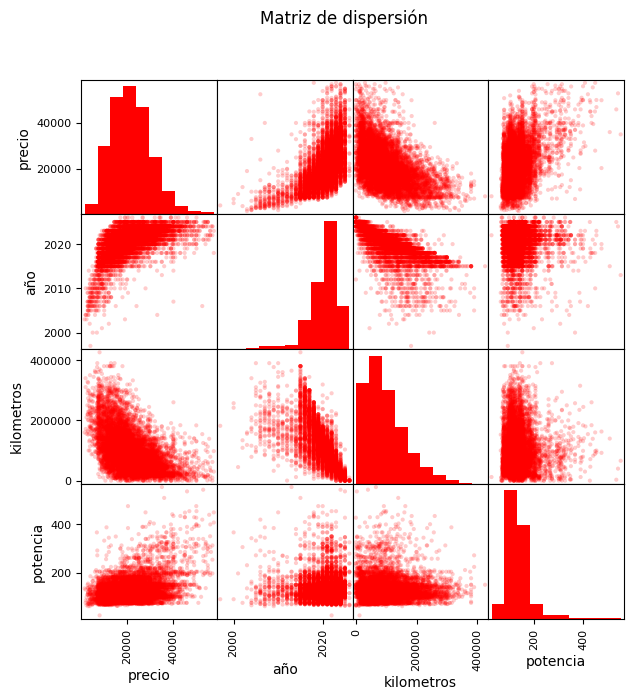

In [ ]:
scatter_matrix(
    df_v,
    alpha=0.2,
    figsize=(7, 7),
    color="red",
    hist_kwds={"color": "red"}
)

plt.suptitle("Matriz de dispersión", color="black")
plt.show()

Aunque los histogramas ya se observan en el gráfico anterior, se presentan nuevamente para detallar con mayor precisión las características del dataset. En este análisis se destaca una concentración de precios alrededor de los 20.000 euros. En cuanto a los kilómetros, se aprecia una mayor concentración entre los 50.000 km, respecto a los años se concentran sobre el 2022. Por último, en la variable de potencia se identifica un pico de frecuencia alrededor de los 100 CV, lo que indica una mayor presencia de vehículos con esa motorización.

array([[<Axes: title={'center': 'precio'}>,
        <Axes: title={'center': 'año'}>],
       [<Axes: title={'center': 'kilometros'}>,
        <Axes: title={'center': 'potencia'}>]], dtype=object)

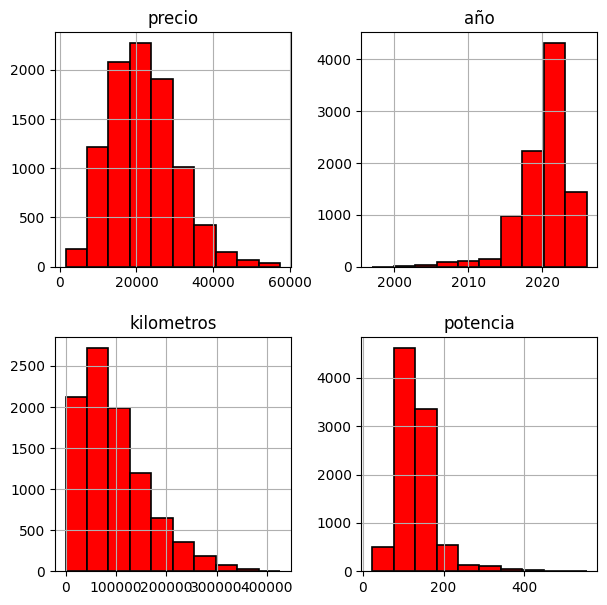

In [ ]:
df_v.hist(figsize=(7,7),color="red",edgecolor="black",linewidth=1.2)

Para evidenciar de manera más clara la línea de tendencia entre el precio y el año, se realiza una agrupación de estas variables calculando su media. A partir de este procesamiento, se genera un gráfico de líneas que permite visualizar de forma más evidente la relación previamente mencionada, confirmando que, a mayor año de matriculación, mayor es el valor de venta del vehículo

In [ ]:
df_line = pd.DataFrame(df_v.groupby('año')["precio"].mean())

In [ ]:
df_line = df_line.reset_index()
df_line.tail(5)

,año,precio
23,2022,23722.594079
24,2023,25846.044787
25,2024,29160.720779
26,2025,28954.410714
27,2026,31636.052632


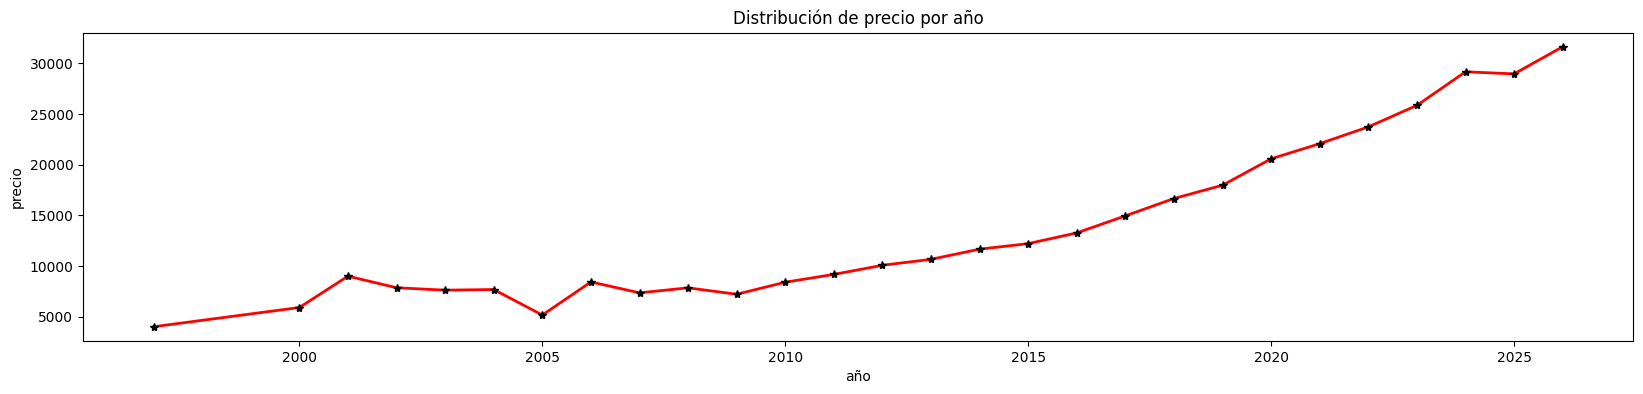

In [ ]:
plt.figure(figsize = (20,4))


plt.plot(df_line['año'], df_line['precio'],
         color='red',
         linewidth= 2,
         marker= '*',
         markerfacecolor='black',
         markeredgecolor='black')

plt.title("Distribución de precio por año")
plt.xlabel('año')
plt.ylabel('precio')

plt.show;

Como se ha mencionado anteriormente, la relación entre el precio y los kilómetros es de carácter inverso. Esto se refleja en la gráfica mediante una línea de tendencia descendente, que indica que los vehículos con menor kilometraje tienden a tener un precio más elevado. A medida que aumenta el número de kilómetros recorridos, el precio del vehículo tiende a disminuir.

In [ ]:
fig = px.scatter(
    df_v,
    x="kilometros",
    y="precio",
    opacity=0.6,
    trendline="ols",
    title="Relación entre kilometros y Precio",
    color_discrete_sequence=["red"]
)

fig.data[1].line.color = "black"

fig.update_layout(
    xaxis_title="kilometros (Km)",
    yaxis_title="Precio",
    template="plotly_white"
)

fig.show()

En esta gráfica se analiza la relación entre el precio y la potencia de los vehículos, añadiendo además el tipo de transmisión como tercera variable. Se puede observar que, en general, a medida que aumenta la potencia del motor, también aumenta el precio del vehículo. Esto tiene sentido, ya que los coches más potentes suelen ser más caros por sus mejores prestaciones.

Además, se aprecia que los vehículos automáticos suelen tener mayor potencia que los manuales y, por ello, también tienden a ser más caros dentro del dataset. Esto sugiere que los coches automáticos suelen pertenecer a gamas más altas o mejor equipadas, lo que influye directamente en su precio.

In [ ]:
import plotly.express as px

fig = px.scatter(
    df_v,
    x="potencia",
    y="precio",
    opacity=0.6,
    color="transmision",
    trendline="ols",
    title="Relación entre Potencia y Precio",
    color_discrete_map={
        "manual": "red",
        "automatica": "black"}
)

fig.update_layout(
    xaxis_title="Potencia (CV)",
    yaxis_title="Precio",
    template="plotly_white"
)

fig.show()

En este gráfico se analiza la relación entre los kilómetros recorridos y el año de matriculación de los vehículos. En términos generales, se observa una tendencia inversa: a medida que aumenta el año (es decir, cuanto más reciente es el vehículo), menor es el número de kilómetros. Esta relación es coherente, ya que los coches más nuevos han tenido menos tiempo de uso.

No obstante, se identifican algunas excepciones puntuales que rompen esta tendencia, como ocurre en ciertos años antiguos (por ejemplo, en torno a 2001), donde aparecen vehículos con pocos kilómetros a pesar de su antigüedad. Estos casos pueden deberse a un uso muy limitado, a vehículos de colección o a posibles particularidades en los datos.

En cuanto a la evolución temporal, la disminución del kilometraje se aprecia de forma más gradual entre los años 2005 y 2014, mientras que a partir de 2015 la caída es mucho más pronunciada. Esto indica que los vehículos más recientes presentan una reducción más significativa en el número de kilómetros, reforzando la relación negativa entre ambas variables.

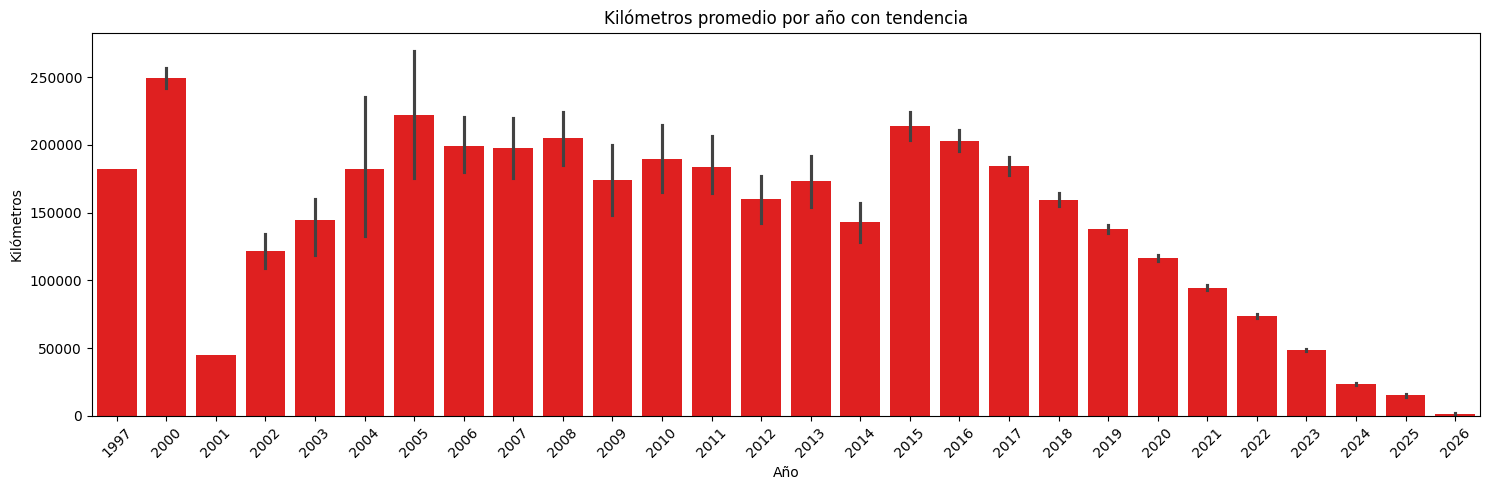

In [ ]:
plt.figure(figsize=(15,5))

sns.barplot(
    x='año',
    y='kilometros',
    data=df_v,
    palette=["red"]
)

plt.title("Kilómetros promedio por año con tendencia")
plt.xlabel("Año")
plt.ylabel("Kilómetros")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


## 2.4 Hipótesis únicas coches.net



### Preguntas clave

- ¿Cuál es el ranking de los vehículos más caros?
- ¿Qué modelos aparecen con mayor frecuencia en el dataset?
- ¿Cuál es el precio medio por marca?
- ¿Qué tipo de combustible presenta el precio medio más elevado?
- ¿Existen diferencias de kilometraje según el tipo de carrocería?
- ¿Existen valores atípicos en el precio?
- ¿Existen valores atípicos en los kilómetros?

**¿Cuál es el ranking de los vehículos más caros?**

Tras aplicar filtros para eliminar valores extremos, se observa que los 10 vehículos más caros del dataset presentan precios comprendidos entre aproximadamente 55.900 y 57.500 euros. Dentro de este grupo, el modelo más costoso es el Mercedes-Benz Clase C, seguido del Audi A4, lo que indica una clara presencia de vehículos de gama media-alta en la parte superior del rango de precios.

Asimismo, al analizar las marcas con los precios más elevados dentro del dataset, se observa el siguiente orden: en primer lugar, Mercedes-Benz, seguido de Audi, Mazda, BMW y, finalmente, Ford.

In [ ]:
df_v.sort_values(by="precio", ascending=False).head(10)

,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
7998,mercedes-benz,clase c,57500.0,2023,29990.0,hibrido,automatica,408,coches.net,berlina
7591,audi,a4,57490.0,2018,98000.0,gasolina,automatica,450,coches.net,berlina
6141,mercedes-benz,glc,56900.0,2022,62000.0,hibrido,automatica,197,coches.net,utilitario
5947,mazda,cx-80,56900.0,2024,9900.0,hibrido,automatica,254,coches.net,utilitario
8757,mercedes-benz,clase c,56900.0,2024,15.0,hibrido,automatica,313,coches.net,berlina
8000,bmw,serie 4,56300.0,2024,31448.0,hibrido,automatica,286,coches.net,berlina
7970,audi,a3,55990.0,2022,79372.0,gasolina,automatica,400,coches.net,berlina
7972,mercedes-benz,clase a,55970.0,2023,34901.0,gasolina,automatica,306,coches.net,berlina
9266,mercedes-benz,clase e,55900.0,2022,14900.0,hibrido,automatica,200,coches.net,berlina
6538,mercedes-benz,clase v,55900.0,2023,43451.0,diesel,automatica,190,coches.net,utilitario


**¿Qué modelos aparecen con mayor frecuencia en el dataset?**

Los modelos más frecuentes en el dataset están claramente concentrados en vehículos comerciales. En primer lugar, destaca el Iveco Daily con 345 registros, seguido del Ford Transit Connect con 265 y el Ford Transit con 250. En cuarta posición se encuentra el Volkswagen Transporter con 232 registros, mientras que el quinto lugar lo ocupa el Ford Transit Courier con 223.


In [ ]:
df_v.groupby(['marca', 'modelo']).size().sort_values(ascending=False).head(5)


marca       modelo         
iveco       daily              345
ford        transit connect    265
            transit            250
volkswagen  transporter        232
ford        transit courier    223
dtype: int64

**¿Cuál es el precio medio por marca?**

Al analizar el precio medio por marca, se observa que las más caras son Polestar, con una media de 44.990 €, seguida de Maserati (40.193,75 €), Ebro (37.644 €), Porsche (36.005,36 €) y Jaecoo (32.866,67 €). Esto indica que estas marcas están asociadas a vehículos de gama más alta o con mejores prestaciones, lo que explica sus precios más elevados.

En el otro extremo, encontramos marcas con precios medios mucho más bajos, como Smart (10.798,55 €), Zhidou (7.990 €), Chevrolet (6.522 €), Lancia (4.990 €) y Dodge (3.450 €). Esto muestra que dentro del dataset hay una gran diferencia entre marcas, ya que conviven tanto opciones económicas como vehículos de gama alta.

In [ ]:
df_v.groupby("marca")["precio"].mean().round(2).sort_values(ascending=False).head(5)

,precio
marca,
polestar,44990.00
maserati,40193.75
ebro,37644.00
porsche,36005.36
jaecoo,32866.67


In [ ]:
df_v.groupby("marca")["precio"].mean().round(2).sort_values(ascending=False).tail(5)

,precio
marca,
smart,10798.55
zhidou,7990.00
chevrolet,6522.00
lancia,4990.00
dodge,3450.00


**¿Qué tipo de combustible presenta el precio más elevado?**

El gráfico permite observar diferencias significativas entre categorías. Los vehículos eléctricos presentan el precio medio más elevado, situándose en torno a los 26.100 euros. A continuación, se encuentran los vehículos híbridos, con una media aproximada de 24.100 euros.

En una posición intermedia se sitúan los vehículos de gas, con un precio medio cercano a los 21.100 euros, seguidos por los diésel, cuya media ronda los 20.800 euros. Por último, los vehículos de gasolina son los que presentan el precio medio más bajo, con aproximadamente 17.500 euros.

Estos valores, expresados de forma redondeada, permiten una interpretación más clara de la gráfica interactiva y facilitan la comparación entre los distintos tipos de combustible.

In [ ]:
fig = px.box(
    df_v,
    x="combustible",
    y="precio",
    title="Distribución del precio por tipo de combustible",
    width=1000,
    height=500
)
fig.update_traces(
    marker_color="red",
    line_color="black"
)
fig.update_layout(
    template="plotly_white"
)

fig.show()

**¿Existen diferencias de kilometraje según el tipo de carrocería?**

Para analizar las diferencias de kilometraje según el tipo de carrocería, se calculó el promedio de kilómetros para cada categoría. Los resultados muestran que las pick-up presentan la media más alta, con aproximadamente 85.000 km, seguidas de las furgonetas con unos 84.000 km y las berlinas con cerca de 82.000 km. Por último, los vehículos utilitarios son los que registran el menor kilometraje medio, con alrededor de 74.000 km. Estos valores, expresados de forma redondeada, permiten interpretar con mayor claridad la gráfica.

Además, la gráfica no solo muestra los valores medios, sino también la dispersión de los datos y la presencia de valores atípicos. En este caso, se identifican outliers en las carrocerías de furgonetas, berlinas y utilitarios, lo que indica que existen vehículos con kilometrajes significativamente alejados de la media dentro de estas categorías.


In [ ]:
fig = px.box(
    df_v,
    x="kilometros",
    y="carroceria",
    title="Distribución de los kilometros por tipo de carrocería",
    width=1000,
    height=500
)
fig.update_traces(
    marker_color="red",
    line_color="black"
)
fig.update_layout(
    template="plotly_white"
)

fig.show()

**¿Existen valores atípicos en el precio?**

A partir del análisis estadístico, se observa que el precio medio es de 21.838,24 €, mientras que la mediana se sitúa en 21.100 €, lo que indica una distribución relativamente centrada, aunque con cierta variabilidad, reflejada en una desviación estándar de 8.813,25 €.

Utilizando el rango intercuartílico (IQR), con un Q1 de 15.500 € y un Q3 de 27.292 €, se establecen los límites para detectar valores atípicos en -2.188,75 € y 44.981,25 €. En base a estos valores, se identifican 328 outliers, lo que representa aproximadamente el 3,52% del total. Esto confirma la presencia de valores atípicos en el precio, principalmente en el extremo superior, correspondientes a vehículos significativamente más caros que la mayoría del dataset.

In [ ]:
precios = df_v["precio"]

media_precio = precios.mean()
mediana_precio = precios.median()
varianza_precio = precios.var(ddof=0)
std_precio = precios.std(ddof=0)

print(f"Media de precio: {media_precio:.2f}")
print(f"Mediana de precio: {mediana_precio:.2f}")
print(f"Varianza de precio: {varianza_precio:.2f}")
print(f"Desviación estándar de precio: {std_precio:.2f}")

Media de precio: 21838.24
Mediana de precio: 21100.00
Varianza de precio: 77673310.02
Desviación estándar de precio: 8813.25


In [ ]:
Q1 = precios.quantile(0.25)
Q3 = precios.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {lower_bound:.2f}")
print(f"Límite superior: {upper_bound:.2f}")

outliers = df_f[(df_f['precio'] < lower_bound) | (df_f['precio'] > upper_bound)]
print(f"Cantidad de outliers: {len(outliers)}")
print(f"Cantidad de outliers: {round(len(outliers)/len(precios)*100,2)}%")

Q1: 15500.00
Q3: 27292.50
IQR: 11792.50
Límite inferior: -2188.75
Límite superior: 44981.25
Cantidad de outliers: 328
Cantidad de outliers: 3.52%


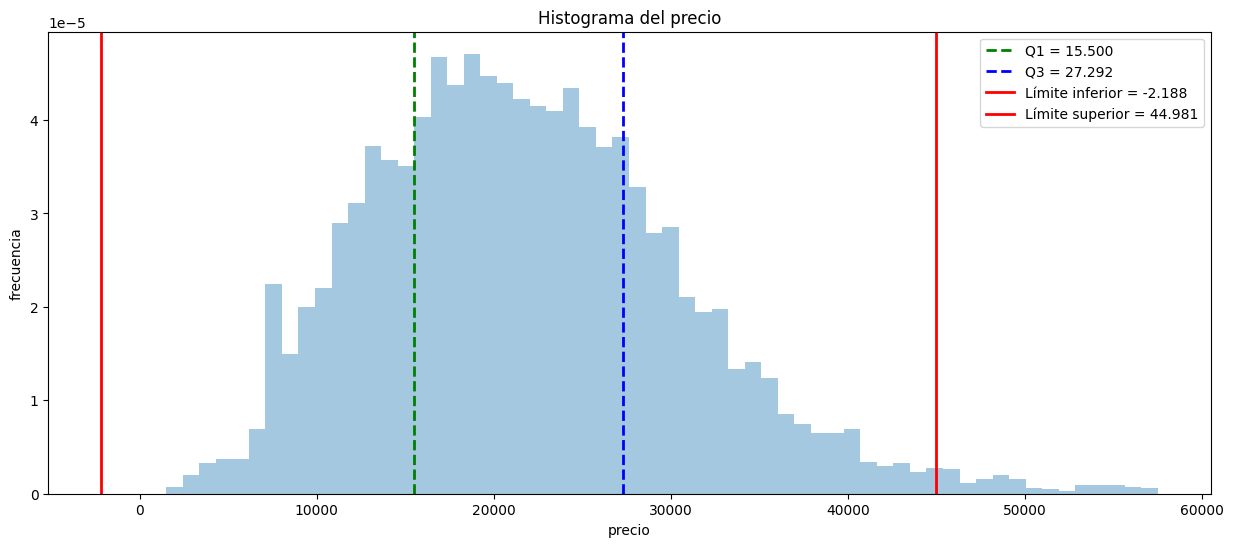

In [ ]:
plt.figure(figsize=(15,6))

plt.hist(precios, bins=60, density=True, alpha=0.4)
# Líneas verticales
plt.axvline(Q1, color='green', linestyle='--', linewidth=2, label='Q1 = 15.500')
plt.axvline(Q3, color='blue', linestyle='--', linewidth=2, label='Q3 = 27.292')

plt.axvline(lower_bound, color='red', linestyle='-', linewidth=2, label='Límite inferior = -2.188')
plt.axvline(upper_bound, color='red', linestyle='-', linewidth=2, label='Límite superior = 44.981')


plt.xlabel('precio')
plt.ylabel('frecuencia')
plt.title('Histograma del precio')
plt.legend()
plt.show()


**¿Existen valores atípicos en los kilómetros**

Para analizar la presencia de valores atípicos en los kilómetros, se utilizó el rango intercuartílico. Los resultados muestran un Q1 de 45.600 km y un Q3 de 132.500 km, lo que da lugar a un IQR de 86.900 km. A partir de estos valores, se establecen los límites en -84.750 km y 262.750 km.

Con estos umbrales, se identifican 247 valores atípicos, lo que representa aproximadamente el 2,65% del total del dataset. Esto indica que, aunque la mayoría de los vehículos se concentra dentro de un rango de kilometraje razonable, existen algunos casos con valores significativamente más altos que se alejan del comportamiento general.

In [ ]:
km = df_v["kilometros"]

In [ ]:
Q1_km = km.quantile(0.25)
Q3_km = km.quantile(0.75)
IQR_km = Q3_km - Q1_km

lower_bound_km = Q1_km - 1.5 * IQR_km
upper_bound_km = Q3_km + 1.5 * IQR_km

print(f"Q1: {Q1_km:.2f}")
print(f"Q3: {Q3_km:.2f}")
print(f"IQR: {IQR_km:.2f}")
print(f"Límite inferior: {lower_bound_km:.2f}")
print(f"Límite superior: {upper_bound_km:.2f}")

outliers_km = df_f1[(df_f1['kilometros'] < lower_bound_km) | (df_f1['kilometros'] > upper_bound_km)]
print(f"Cantidad de outliers: {len(outliers_km)}")
print(f"Cantidad de outliers: {round(len(outliers_km)/len(km)*100,2)}%")

Q1: 45600.00
Q3: 132500.00
IQR: 86900.00
Límite inferior: -84750.00
Límite superior: 262850.00
Cantidad de outliers: 247
Cantidad de outliers: 2.65%


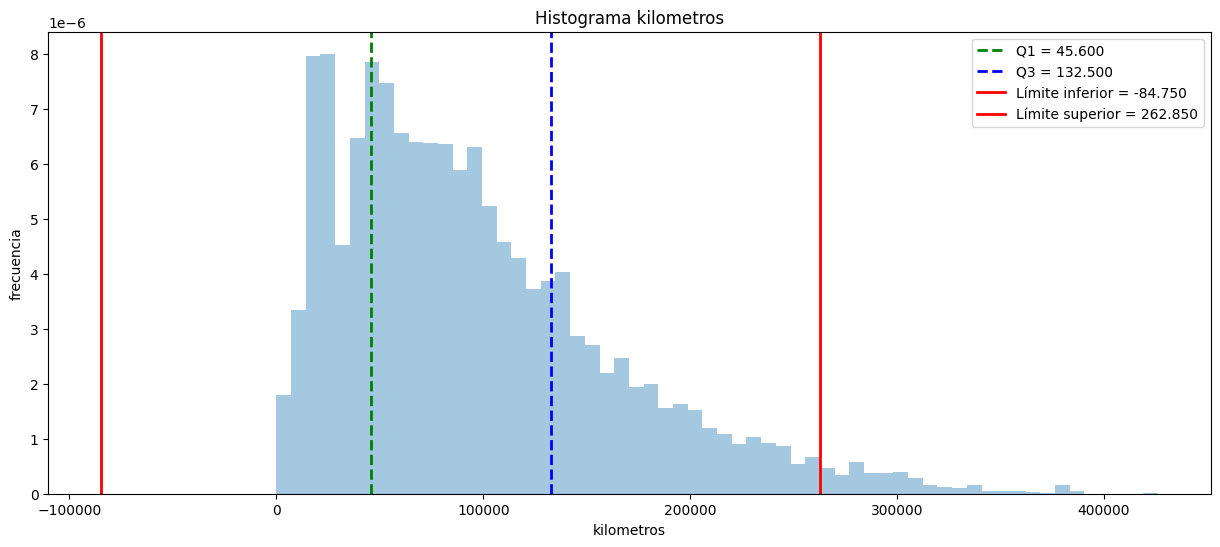

In [ ]:
plt.figure(figsize=(15,6))

plt.hist(km, bins=60, density=True, alpha=0.4)
# Líneas verticales
plt.axvline(Q1_km, color='green', linestyle='--', linewidth=2, label='Q1 = 45.600')
plt.axvline(Q3_km, color='blue', linestyle='--', linewidth=2, label='Q3 = 132.500')

plt.axvline(lower_bound_km, color='red', linestyle='-', linewidth=2, label='Límite inferior = -84.750')
plt.axvline(upper_bound_km, color='red', linestyle='-', linewidth=2, label='Límite superior = 262.850')


plt.xlabel('kilometros')
plt.ylabel('frecuencia')
plt.title('Histograma kilometros')
plt.legend()
plt.show()


Es importante mencionar que en los dos últimos gráficos el límite inferior se establece en valores negativos. Esto se debe a que, estadísticamente, la fórmula para calcular el límite inferior es:

límite inferior = Q1 - 1.5 * IQR

Es decir, al primer cuartil (Q1) se le resta 1.5 veces el rango intercuartílico (IQR). En este caso particular, dicho límite no tiene un significado práctico relevante, pero se deja reflejado en el ejercicio con el fin de mostrar visualmente cómo se comportan los límites.

## 2.5 Conclusiones coches.net

A lo largo del análisis se observa que el precio de los vehículos está principalmente influenciado por variables como el año de matriculación, la potencia y el kilometraje. En general, los coches más recientes y con mayor potencia tienden a tener precios más elevados, mientras que aquellos con mayor número de kilómetros suelen ser más económicos. Esto confirma el comportamiento habitual del mercado de vehículos de segunda mano.

Además, se identifican diferencias claras según el tipo de combustible y la marca. Los vehículos eléctricos e híbridos presentan precios medios más altos, mientras que los de gasolina son los más económicos. Por otro lado, marcas como Polestar, Maserati o Porsche destacan por sus precios elevados, mientras que otras como Dodge o Lancia se sitúan en los rangos más bajos. Esto evidencia que tanto la tecnología como la marca influyen directamente en el valor del vehículo.

También se observa una alta presencia de vehículos comerciales dentro del dataset, ya que modelos como Iveco Daily o Ford Transit aparecen con mucha frecuencia. Esto refleja el peso que tienen este tipo de vehículos dentro de la oferta analizada, especialmente en sectores como el transporte y la logística, donde su uso es más común.

Por último, aunque se detectan valores atípicos tras aplicar filtros para eliminar valores extremos, tanto en el precio como en los kilómetros, estos representan un porcentaje reducido del total, por lo que no distorsionan de forma significativa los resultados del análisis.

### Filtros de negocio

Para consolidar una base de datos óptima que permita dar respuesta a los objetivos del proyecto, se establecieron una serie de filtros sobre los datos: vehículos con un máximo de 120.000 kilómetros, año de matriculación igual o posterior a 2020, un rango de precio entre 10.000 y 20.000 euros, y carrocería tipo berlina, utilitario o furgoneta.

Tras aplicar estos criterios, se obtuvo un total de 1.632 registros, los cuales se integrarán con los datos procedentes de otras plataformas de compraventa de vehículos de segunda mano, con el objetivo de ampliar y enriquecer el dataset final del proyecto.

In [ ]:
dff = df_f1[
    (df_f1['kilometros'] <= 120000) &
    (df_f1["año"] >= 2020) &
    (df_f1["precio"] > 10000) &
    (df_f1["precio"] < 20000) &
    (df_f1["carroceria"].isin(["berlina", "furgoneta", "utilitario"]))
]

dff.reset_index(drop=True, inplace=True)

dff.tail(3)


,marca,modelo,precio,año,kilometros,combustible,transmision,potencia,fuente,carroceria
1629,volkswagen,t-cross,17890.0,2023,58541.0,gasolina,manual,95,coches.net,utilitario
1630,peugeot,308,15990.0,2022,47645.0,gasolina,manual,130,coches.net,berlina
1631,renault,clio,16200.0,2025,35350.0,gasolina,manual,90,coches.net,berlina


### Dataframe final
Documento listo para unir con los demas archivos del proyecto

In [ ]:
df5 = dff.to_csv("5.coches.net_final.csv", index=False)